In [2]:
import matplotlib.pyplot as plt
from helpers import Participant, Condition, Trial

from plotting import plot_trajectory, plot_prepost_comparison
from plotting.preprocessor import generate_prepost_comparison

## Loading Data as Seperate Conditions

The following function loads all data into memory and divides it into experimental groups stored as `Condition` objects serving as wrappers for `Participant` objects. 
If you want to analyse a single participant you can also load him individually by using the `Participant` class.

In [ ]:
#rd, ri, ad, ai = Condition.load_conditional_groups("../data")
#participant = Participant.load_participant("../data/1rd")
rd = Condition.load_conditional_group(condition="rd")

NameError: name 'Condition' is not defined

You can iterate over the participants in a conditional group by using a normal for loop which returns participant objects; The same as received when loading a perticipant individually.

In [ ]:
print(f"{rd.get_participant_count()} particiants in condition '{rd.get_group_name()}'")
for participant in rd:
    print(participant.get_participant_id())

4 particiants in condition 'rd'
data\13rd
data\1rd
data\5rd
data\9rd


You can access a participant on its own and by printing it, see that it is inheriting from a dictionary. The structure of which is representing our experiment structure

In [ ]:
participant = rd.get_participant_by_index(0)
print(participant)
print(participant.get_phases())

{
    Pre-Test:{
        1: 112 trials,
    },
    Training:{
        1: 40 trials,
        2: 40 trials,
        3: 40 trials,
        4: 40 trials,
        5: 40 trials,
    },
    Post-Test:{
        1: 112 trials,
    },
    Recap:{
        1: 40 trials,
    },
}
['Pre-Test', 'Training', 'Post-Test', 'Recap']


You could iterate over the trials (represented by the class `Trial`) of a participant the same way as iterating over participants in group or access an individual trial. The `Trial` class inherits directly from `pandas.DataFrame` which means besides the custom methods you can manipulate a single trial object like you would any other `DataFrame`.

In [ ]:
for trial in participant:
    print(trial.print_short())

Trial: 1, Task: avoiding, Mapping: direct
Trial: 2, Task: avoiding, Mapping: direct
Trial: 3, Task: avoiding, Mapping: direct
Trial: 4, Task: avoiding, Mapping: direct
Trial: 5, Task: avoiding, Mapping: direct
Trial: 6, Task: avoiding, Mapping: direct
Trial: 7, Task: avoiding, Mapping: direct
Trial: 8, Task: avoiding, Mapping: direct
Trial: 9, Task: avoiding, Mapping: direct
Trial: 10, Task: avoiding, Mapping: direct
Trial: 11, Task: avoiding, Mapping: direct
Trial: 12, Task: avoiding, Mapping: direct
Trial: 13, Task: avoiding, Mapping: direct
Trial: 14, Task: avoiding, Mapping: direct
Trial: 15, Task: avoiding, Mapping: direct
Trial: 16, Task: avoiding, Mapping: direct
Trial: 17, Task: avoiding, Mapping: direct
Trial: 18, Task: avoiding, Mapping: direct
Trial: 19, Task: avoiding, Mapping: direct
Trial: 20, Task: avoiding, Mapping: direct
Trial: 21, Task: avoiding, Mapping: direct
Trial: 22, Task: avoiding, Mapping: direct
Trial: 23, Task: avoiding, Mapping: direct
Trial: 24, Task: avo

In [6]:
trial = participant.get_trial(288)
print(trial.get_target())

# Here you see the same behavior as above but as pandas DataFrame (which is used in the underlying methods)
print(trial[["target_pos_x", "target_pos_y"]].iloc[0]) 

# To get a single trial from a block / phase
participant["Training"][5]

(-26.05, -564.89)
target_pos_x    -26.05
target_pos_y   -564.89
Name: 0, dtype: float64


[   participant_id  trial_index      task mapping     phase  block  \
 0            13rd          273  reaching  direct  Training      5   
 1            13rd          273  reaching  direct  Training      5   
 2            13rd          273  reaching  direct  Training      5   
 3            13rd          273  reaching  direct  Training      5   
 4            13rd          273  reaching  direct  Training      5   
 5            13rd          273  reaching  direct  Training      5   
 6            13rd          273  reaching  direct  Training      5   
 7            13rd          273  reaching  direct  Training      5   
 8            13rd          273  reaching  direct  Training      5   
 9            13rd          273  reaching  direct  Training      5   
 10           13rd          273  reaching  direct  Training      5   
 11           13rd          273  reaching  direct  Training      5   
 12           13rd          273  reaching  direct  Training      5   
 13           13rd  

Or you can access all trials in a given phase and or block (Without parameters you get all trials)

In [7]:
trials = participant.get_as_one_dataframe(phase="Training")
#trials = participant.get_as_one_dataframe(phase="Training", block=1)
print(len(trials))

200


For now i wrote a simple method to plot the trajectory. I hope these helper methods will make the data analysis a bit more easy and faster

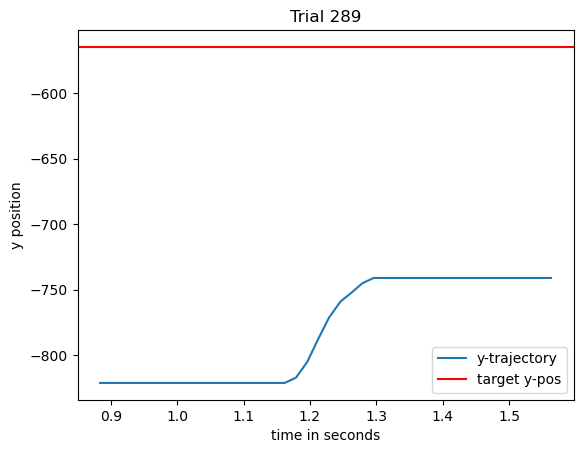

In [8]:
plot_trajectory(trial)

### Pre-/Post-Test Comparisons

In [9]:
from itertools import chain

With the generate functions we can preprocess the data so that we can immediately plot it. We can fully customize all allowed states which we want to mix and plot from each participant. For this we can use such a dictionary as provided below with 'tasks' = ['avoiding', 'reaching'] or ['avoiding'], etc. and 'mappings' = ['direct', 'reversed'].

When we plot our data we must be aware that `plot_prepost_comparison` does *not* show the plot and returns the figure and axes which can be further customized. This means we always need to call `plt.show()` after we call a plotting function. Code might diverge in this regard, so always check the source code itself.

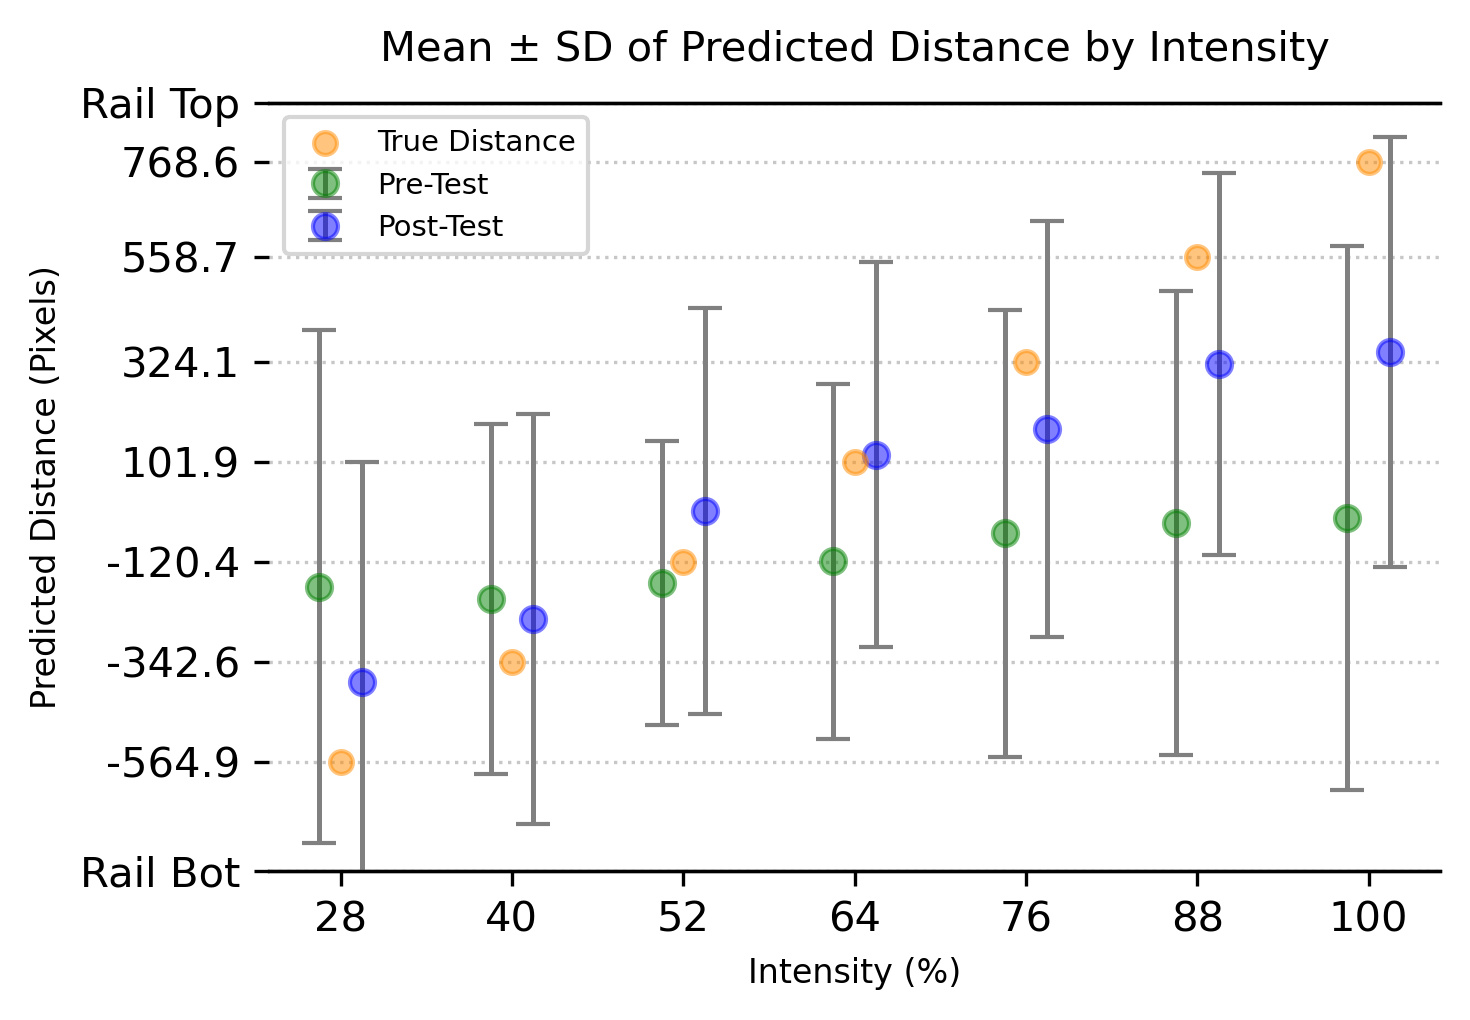

In [ ]:
allowed_states = {
    'tasks':     ['avoiding', 'reaching'], 
    'mappings':  ['direct'], 
}

pre_data_meanstds, post_data_meanstds = generate_prepost_comparison(
    chain(*[ad, rd]), # Here we use both avoid direct and reaching direct for a summarized comparison
    allowed_states.copy(), # Do not forget to coppy since we work with it internally. TODO: Incorporate those points into the functions.
    allowed_states.copy(), 
)
plot_prepost_comparison(pre_data_meanstds, post_data_meanstds, 'direct')
plt.show()